In [5]:
# ============================================================
# VERIFICA LOCALE: la ricostruzione corrisponde al sinogramma?
# ============================================================
# Da eseguire sul tuo PC (non Colab). Serve IPPy + astra-toolbox anche in
# locale, ma solo su CPU (force_cpu=True) -- per un controllo su una
# singola immagine va benissimo, non serve GPU.
#
# Installazione (una tantum), da terminale:
#   pip install astra-toolbox
#   pip install git+https://github.com/devangelista2/IPPy.git
#
# Le ruote pip includono il supporto CPU out-of-the-box su Windows/Linux/Mac
# (nessuna GPU richiesta per questo script). Se l'installazione dovesse
# fallire, mandami il messaggio di errore esatto.

import numpy as np
import torch
from IPPy import operators

# ------------------------------------------------------------
# MODIFICA QUI
# ------------------------------------------------------------
SINOGRAM_PATH = "imageProva/55c_90_train_sino.npy"
RECON_PATH = "imageProva/55c_90_train_rec.npy"
N_ANGLES = 90                          # <-- 90, 45, 30 o 15: la configurazione a cui appartengono
IMG_SIZE = (256, 256)                  # <-- dimensione delle immagini originali
THRESHOLD = 0.02                        # <-- soglia oltre la quale il residuo è sospetto

# Stessa identica definizione degli angoli usata nel notebook di generazione
# sinogrammi (geometria "parallel", stesso trucco [1:-1] per 30/15) --
# NON toccare a meno che tu non abbia cambiato anche lì.
ANGLE_CONFIGS_DEG = {
    90: np.linspace(-45, 45, 90),
    45: np.linspace(-45, 45, 45),
    30: np.linspace(-30, 30, 32)[1:-1],
    15: np.linspace(-30, 30, 17)[1:-1],
}

# ------------------------------------------------------------

def build_projector(n_angles, img_size):
    angles_deg = ANGLE_CONFIGS_DEG[n_angles]
    return operators.CTProjector(
        img_shape=img_size,
        angles=np.deg2rad(angles_deg),
        geometry="parallel",
        force_cpu=True,   # in locale, niente GPU: va bene per un controllo singolo
    )


def verify_pair(sinogram_path, recon_path, n_angles, img_size, threshold=0.2):
    K = build_projector(n_angles, img_size)

    y_true = torch.from_numpy(np.load(sinogram_path)).float().unsqueeze(0).unsqueeze(0)
    x_sol = torch.from_numpy(np.load(recon_path)).float().unsqueeze(0).unsqueeze(0)

    print(f"Shape sinogramma: {tuple(y_true.shape)}")
    print(f"Shape ricostruzione: {tuple(x_sol.shape)}")

    with torch.no_grad():
        y_pred = K(x_sol)   # riproietta la ricostruzione con lo stesso operatore

    residual = (torch.norm(y_pred - y_true) / torch.norm(y_true)).item()

    print(f"\nAngoli usati per la verifica: {n_angles}")
    print(f"Residuo relativo ||K(x_sol) - y|| / ||y|| = {residual:.4f}")

    if residual < threshold:
        print(f"OK: sotto la soglia ({threshold}) -- la coppia è coerente.")
    else:
        print(f"‼️ SOSPETTO: sopra la soglia ({threshold}) -- la coppia NON sembra coerente "
              f"(file corrotto/scambiato, angoli sbagliati, o path errato).")

    return residual


if __name__ == "__main__":
    verify_pair(SINOGRAM_PATH, RECON_PATH, N_ANGLES, IMG_SIZE, THRESHOLD)

Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
Shape sinogramma: (1, 1, 90, 364)
Shape ricostruzione: (1, 1, 256, 256)

Angoli usati per la verifica: 90
Residuo relativo ||K(x_sol) - y|| / ||y|| = 0.0054
OK: sotto la soglia (0.02) -- la coppia è coerente.


imageProva/60_90_train_sino.npy: shape=(90, 364), min=-0.7855, max=73.2170
imageProva/60b_90_train_sino.npy: shape=(90, 364), min=-0.6973, max=72.0372


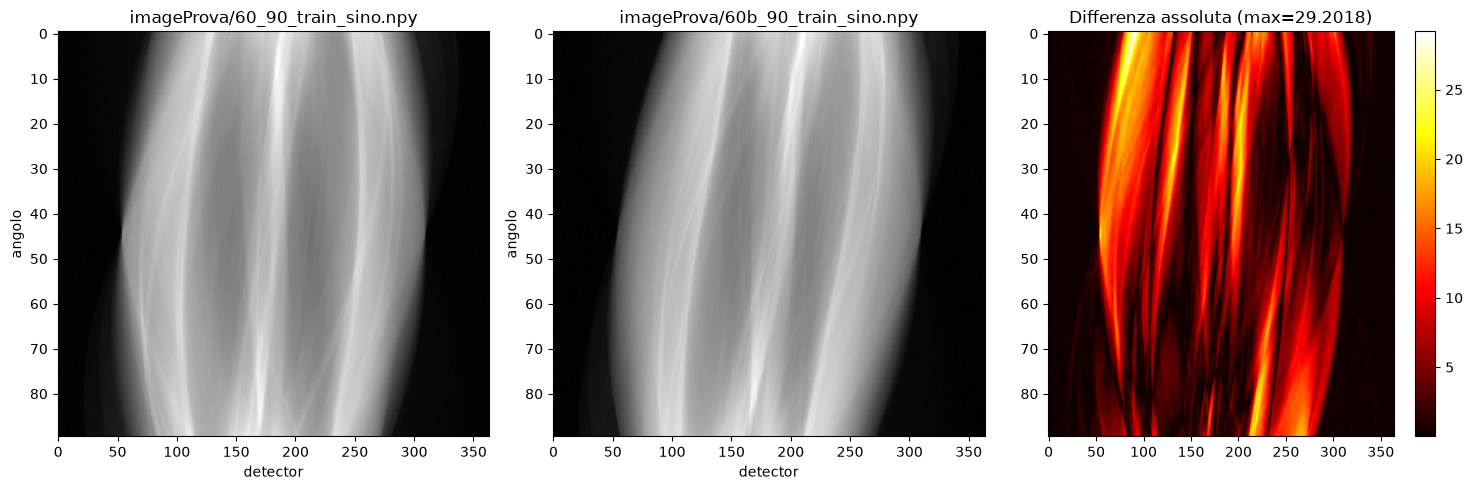

In [ ]:
# ============================================================
# VISUALIZZAZIONE: confronta a occhio due sinogrammi
# ============================================================
# Da eseguire in locale. Serve solo numpy + matplotlib, niente IPPy/astra.

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# MODIFICA QUI: i due file da aprire e confrontare
# ------------------------------------------------------------
SINO_A_PATH = "imageProva/60_90_train_sino.npy"
SINO_B_PATH = "imageProva/60b_90_train_sino.npy"

sino_a = np.load(SINO_A_PATH)
sino_b = np.load(SINO_B_PATH)

print(f"{SINO_A_PATH}: shape={sino_a.shape}, min={sino_a.min():.4f}, max={sino_a.max():.4f}")
print(f"{SINO_B_PATH}: shape={sino_b.shape}, min={sino_b.min():.4f}, max={sino_b.max():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sino_a, cmap="gray", aspect="auto")
axes[0].set_title(SINO_A_PATH)
axes[0].set_xlabel("detector")
axes[0].set_ylabel("angolo")

axes[1].imshow(sino_b, cmap="gray", aspect="auto")
axes[1].set_title(SINO_B_PATH)
axes[1].set_xlabel("detector")
axes[1].set_ylabel("angolo")

# differenza assoluta: se sono uguali/molto simili sarà quasi tutta nera
if sino_a.shape == sino_b.shape:
    diff = np.abs(sino_a - sino_b)
    im = axes[2].imshow(diff, cmap="hot", aspect="auto")
    axes[2].set_title(f"Differenza assoluta (max={diff.max():.4f})")
    plt.colorbar(im, ax=axes[2])
else:
    axes[2].text(0.5, 0.5, "Shape diverse,\nniente confronto diretto",
                  ha="center", va="center")
    axes[2].axis("off")

plt.tight_layout()
plt.show()